In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [26]:
df = pd.read_csv(r"..\data\spamhamdata.csv", sep="\t", header=None, names=["label", "text"])
df = df.dropna()

print("Shape of dataset:", df.shape)
print("Target classes:", df["label"].unique())

df.head()

Shape of dataset: (5572, 2)
Target classes: ['ham' 'spam']


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


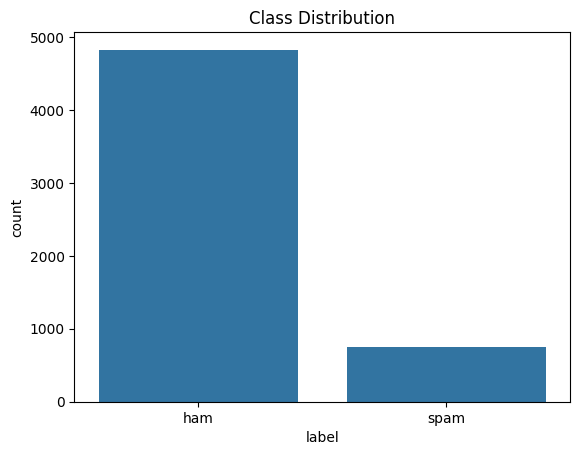

In [27]:
sns.countplot(x=df["label"])
plt.title("Class Distribution")
plt.show()

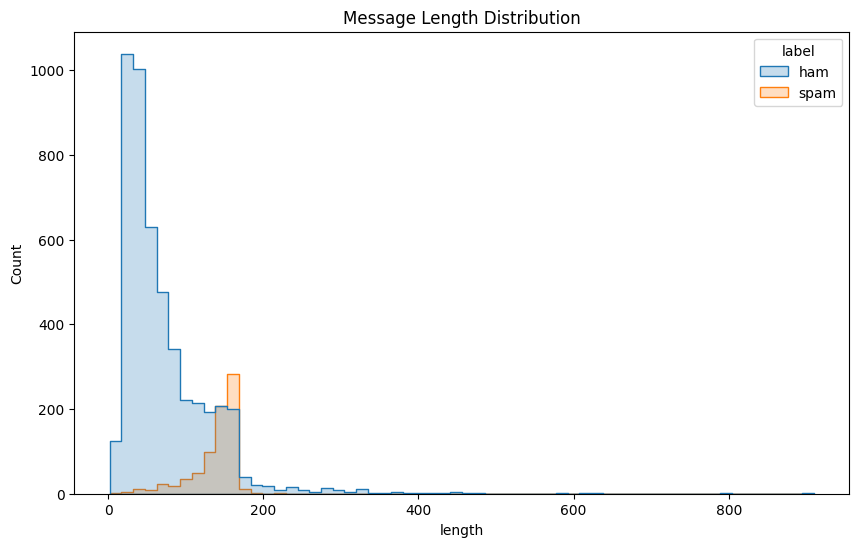

In [28]:
df["length"] = df["text"].str.len()

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="length", hue="label", bins=60, element="step")
plt.title("Message Length Distribution")
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

In [30]:
vectorizer = TfidfVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [31]:
svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [32]:
y_pred = svm_model.predict(X_test_vec)

In [33]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9838565022421525


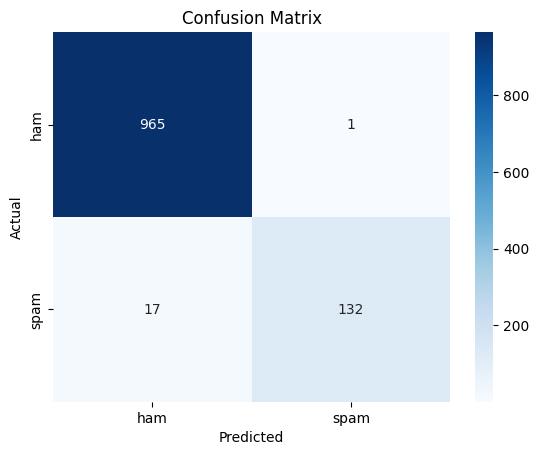

In [34]:
labels = ["ham", "spam"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [36]:
sample_texts = [
    "Congratulations! You have won a free ticket. Reply WIN now.",
    "Hey, are we still meeting for lunch today?",
]

sample_vec = vectorizer.transform(sample_texts)
sample_pred = svm_model.predict(sample_vec)

for text, label in zip(sample_texts, sample_pred):
    print(f"{label.upper()}: {text}")

SPAM: Congratulations! You have won a free ticket. Reply WIN now.
HAM: Hey, are we still meeting for lunch today?
